<a href="https://colab.research.google.com/github/Vivek-ML001/BiharElection/blob/main/biharelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('/content/IndiaVotes_AC__Bihar_[2000_Onwards]_2020.csv')

print(df)

         AC Name  AC No.  Type   District       Winning Candidate  \
0         Agiaon     195   NaN    Bhojpur            Manoj Manzil   
1         Agiaon     195   NaN    Bhojpur            Manoj Manzil   
2      Alamnagar      70   NaN  Madhepura  Narendra Narayan Yadav   
3      Alamnagar      70   NaN  Madhepura  Narendra Narayan Yadav   
4         Alauli     148   NaN   Khagaria          Ramvriksh Sada   
..           ...     ...   ...        ...                     ...   
481  Warsaliganj     239   NaN     Nawada              Aruna Devi   
482    Wazirganj     234   NaN       Gaya          Birendra Singh   
483    Wazirganj     234   NaN       Gaya          Birendra Singh   
484      Ziradei     106   NaN      Siwan       Amarjeet Kushwaha   
485      Ziradei     106   NaN      Siwan       Amarjeet Kushwaha   

                                                 Party  Total Electors  \
0    Communist Party Of India (Marxist-Leninist) (L...          259645   
1    Communist Party Of

In [ ]:
df.shape

(486, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AC Name            486 non-null    object 
 1   AC No.             486 non-null    int64  
 2   Type               0 non-null      float64
 3   District           486 non-null    object 
 4   Winning Candidate  486 non-null    object 
 5   Party              486 non-null    object 
 6   Total Electors     486 non-null    int64  
 7   Total Votes        486 non-null    int64  
 8   Poll%              486 non-null    object 
 9   Margin             486 non-null    int64  
 10  Margin %           486 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 41.9+ KB


In [ ]:
df.head()

,AC Name,AC No.,Type,District,Winning Candidate,Party,Total Electors,Total Votes,Poll%,Margin,Margin %
0,Agiaon,195,NaN,Bhojpur,Manoj Manzil,Communist Party Of India (Marxist-Leninist) (L...,259645,136829,52.7 %,48550,35.5%
1,Agiaon,195,NaN,Bhojpur,Manoj Manzil,Communist Party Of India (Marxist-Leninist) (L...,259645,136829,52.7 %,48550,35.5%
2,Alamnagar,70,NaN,Madhepura,Narendra Narayan Yadav,Janata Dal (United),327866,208234,63.5 %,28680,13.8%
3,Alamnagar,70,NaN,Madhepura,Narendra Narayan Yadav,Janata Dal (United),327866,208234,63.5 %,28680,13.8%
4,Alauli,148,NaN,Khagaria,Ramvriksh Sada,Rashtriya Janata Dal,237047,141583,59.7 %,2773,2.0%


In [ ]:
#  rows of the DataFrame
df.tail()

,AC Name,AC No.,Type,District,Winning Candidate,Party,Total Electors,Total Votes,Poll%,Margin,Margin %
481,Warsaliganj,239,NaN,Nawada,Aruna Devi,Bharatiya Janta Party,341082,167116,49.0 %,9030,5.4%
482,Wazirganj,234,NaN,Gaya,Birendra Singh,Bharatiya Janta Party,303150,174241,57.5 %,22430,12.9%
483,Wazirganj,234,NaN,Gaya,Birendra Singh,Bharatiya Janta Party,303150,174241,57.5 %,22430,12.9%
484,Ziradei,106,NaN,Siwan,Amarjeet Kushwaha,Communist Party Of India (Marxist-Leninist) (L...,270736,139606,51.6 %,25510,18.3%
485,Ziradei,106,NaN,Siwan,Amarjeet Kushwaha,Communist Party Of India (Marxist-Leninist) (L...,270736,139606,51.6 %,25510,18.3%


In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
AC Name                0
AC No.                 0
Type                 486
District               0
Winning Candidate      0
Party                  0
Total Electors         0
Total Votes            0
Poll%                  0
Margin                 0
Margin %               0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

print("\nDataFrame after removing duplicate rows:")
print(df)
print("\nShape after removing duplicate rows:", df.shape)


DataFrame after removing duplicate rows:
          AC Name  AC No.  Type            District  \
0          Agiaon     195   NaN             Bhojpur   
2       Alamnagar      70   NaN           Madhepura   
4          Alauli     148   NaN            Khagaria   
6        Alinagar      81   NaN           Darbhanga   
8         Amarpur     159   NaN               Banka   
..            ...     ...   ...                 ...   
476  Valmikinagar       1   NaN  Pashchim Champaran   
478    Warisnagar     132   NaN          Samastipur   
480   Warsaliganj     239   NaN              Nawada   
482     Wazirganj     234   NaN                Gaya   
484       Ziradei     106   NaN               Siwan   

                            Winning Candidate  \
0                                Manoj Manzil   
2                      Narendra Narayan Yadav   
4                              Ramvriksh Sada   
6                            Mishri Lal Yadav   
8                                  Jayant Raj   
.. 

In [ ]:
# Replace ',' with '.' if necessary to ensure correct float conversion
df['Margin %'] = df['Margin %'].str.replace('%', '').str.replace(',', '.').astype(float)

# df['Margin %'] = df['Margin %'] / 100

df = df.dropna(subset=['Margin %', 'Total Votes', 'Poll%'])  # ensure core fields are clean

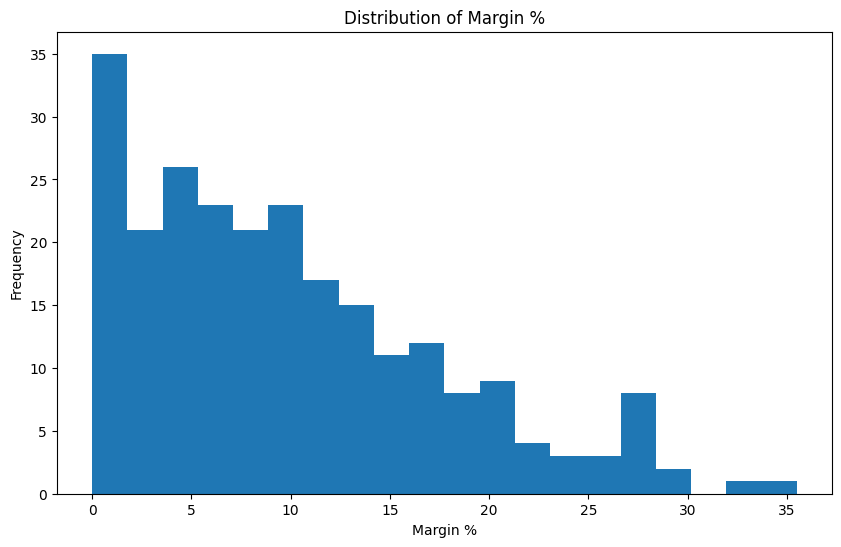

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['Margin %'].hist(bins=20)
plt.title('Distribution of Margin %')
plt.xlabel('Margin %')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

In [ ]:

print("\nDescriptive Statistics for Numeric Columns:")
print(df.describe())


Descriptive Statistics for Numeric Columns:
           AC No.  Type  Total Electors    Total Votes        Margin  \
count  243.000000   0.0      243.000000     243.000000    243.000000   
mean   122.000000   NaN   290540.625514  170499.452675  16888.238683   
std     70.292247   NaN    30718.946763   17103.182353  12988.638725   
min      1.000000   NaN   215424.000000  116527.000000     12.000000   
25%     61.500000   NaN   270341.500000  158666.500000   6373.500000   
50%    122.000000   NaN   290013.000000  169674.000000  14225.000000   
75%    182.500000   NaN   308774.500000  182129.500000  24545.000000   
max    243.000000   NaN   448946.000000  221799.000000  53597.000000   

         Margin %  
count  243.000000  
mean     9.963374  
std      7.719125  
min      0.000000  
25%      3.900000  
50%      8.300000  
75%     14.350000  
max     35.500000  


In [ ]:

print("\nDistribution of Parties:")
print(df['Party'].value_counts())


Distribution of Parties:
Party
Rashtriya Janata Dal                                        75
Bharatiya Janta Party                                       74
Janata Dal (United)                                         43
Indian National Congress                                    19
Communist Party Of India (Marxist-Leninist) (Liberation)    12
All India Majlis-E-Ittehadul Muslimeen                       5
Vikassheel Insaan Party                                      4
Hindustani Awam Morcha (Secular)                             4
Communist Party Of India                                     2
Communist Party Of India (Marxist)                           2
Bahujan Samaj Party                                          1
Independent                                                  1
Lok Jan Shakti Party                                         1
Name: count, dtype: int64


In [ ]:
# average 'Margin %' per party
average_margin_per_party = df.groupby('Party')['Margin %'].mean().sort_values(ascending=False)

print("\nAverage Margin % per Party:")
print(average_margin_per_party)


Average Margin % per Party:
Party
Communist Party Of India (Marxist)                          20.850000
All India Majlis-E-Ittehadul Muslimeen                      18.520000
Communist Party Of India                                    14.600000
Communist Party Of India (Marxist-Leninist) (Liberation)    14.500000
Bahujan Samaj Party                                         11.800000
Bharatiya Janta Party                                       11.241892
Rashtriya Janata Dal                                         9.929333
Indian National Congress                                     7.821053
Janata Dal (United)                                          7.120930
Vikassheel Insaan Party                                      5.450000
Hindustani Awam Morcha (Secular)                             4.525000
Independent                                                  0.300000
Lok Jan Shakti Party                                         0.200000
Name: Margin %, dtype: float64


In [ ]:
df = df[df['Margin %'] >= 0]


In [ ]:
# Display descriptive statistics for numeric columns after filtering
print("\nDescriptive Statistics for Numeric Columns after filtering:")
print(df.describe())


Descriptive Statistics for Numeric Columns after filtering:
           AC No.  Type  Total Electors    Total Votes        Margin  \
count  243.000000   0.0      243.000000     243.000000    243.000000   
mean   122.000000   NaN   290540.625514  170499.452675  16888.238683   
std     70.292247   NaN    30718.946763   17103.182353  12988.638725   
min      1.000000   NaN   215424.000000  116527.000000     12.000000   
25%     61.500000   NaN   270341.500000  158666.500000   6373.500000   
50%    122.000000   NaN   290013.000000  169674.000000  14225.000000   
75%    182.500000   NaN   308774.500000  182129.500000  24545.000000   
max    243.000000   NaN   448946.000000  221799.000000  53597.000000   

         Margin %  
count  243.000000  
mean     9.963374  
std      7.719125  
min      0.000000  
25%      3.900000  
50%      8.300000  
75%     14.350000  
max     35.500000  


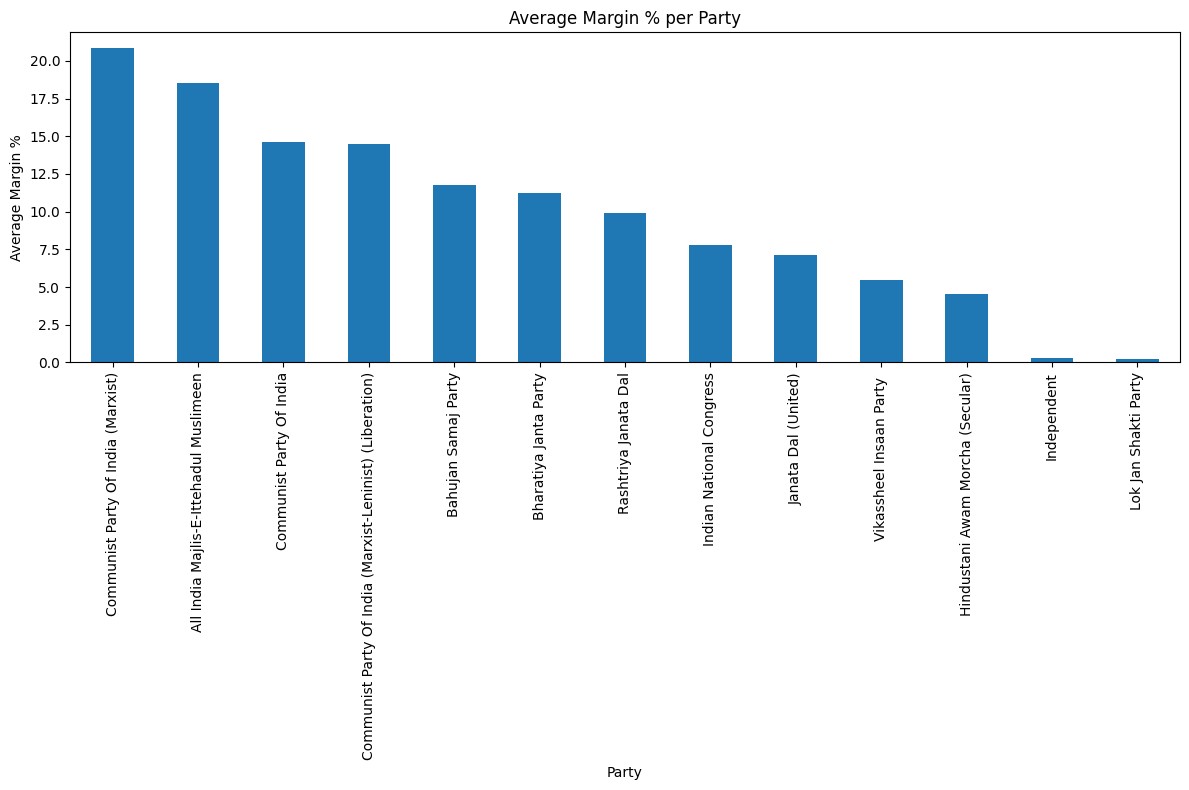

In [ ]:


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
average_margin_per_party.plot(kind='bar')
plt.title('Average Margin % per Party')
plt.xlabel('Party')
plt.ylabel('Average Margin %')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability if there are many parties
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
df = df.reset_index(drop=True)


In [ ]:
def classify_race(margin):
    if margin < 5:
        return 'tight'
    elif margin > 15:
        return 'safe'
    else:
        return 'medium'

df['race_type'] = df['Margin %'].apply(classify_race)
df['race_type'].value_counts()


,count
race_type,
medium,110
tight,77
safe,56


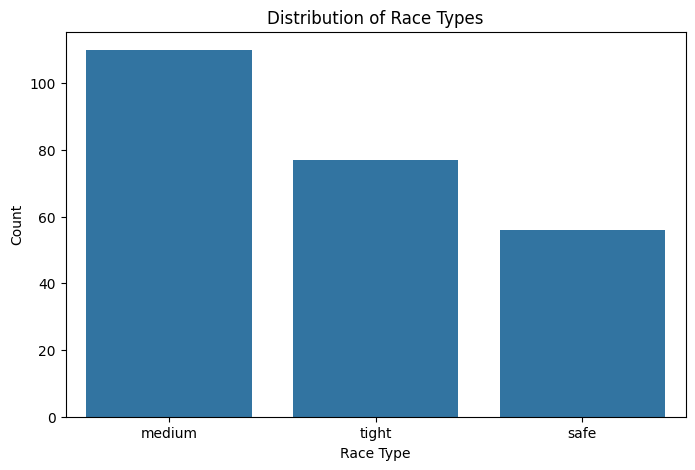

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns # Often useful for creating nicer looking plots

plt.figure(figsize=(8, 5))
sns.countplot(x='race_type', data=df, order=df['race_type'].value_counts().index)
plt.title('Distribution of Race Types')
plt.xlabel('Race Type')
plt.ylabel('Count')
plt.show()

In [ ]:

race_type_by_party = df.groupby('Party')['race_type'].value_counts().unstack(fill_value=0)

print("\nDistribution of Race Types per Party:")
print(race_type_by_party)



Distribution of Race Types per Party:
race_type                                           medium  safe  tight
Party                                                                  
All India Majlis-E-Ittehadul Muslimeen                   1     3      1
Bahujan Samaj Party                                      1     0      0
Bharatiya Janta Party                                   37    21     16
Communist Party Of India                                 0     1      1
Communist Party Of India (Marxist)                       0     2      0
Communist Party Of India (Marxist-Leninist) (Li...       7     4      1
Hindustani Awam Morcha (Secular)                         1     0      3
Independent                                              0     0      1
Indian National Congress                                 6     3     10
Janata Dal (United)                                     20     6     17
Lok Jan Shakti Party                                     0     0      1
Rashtriya Janata Dal     

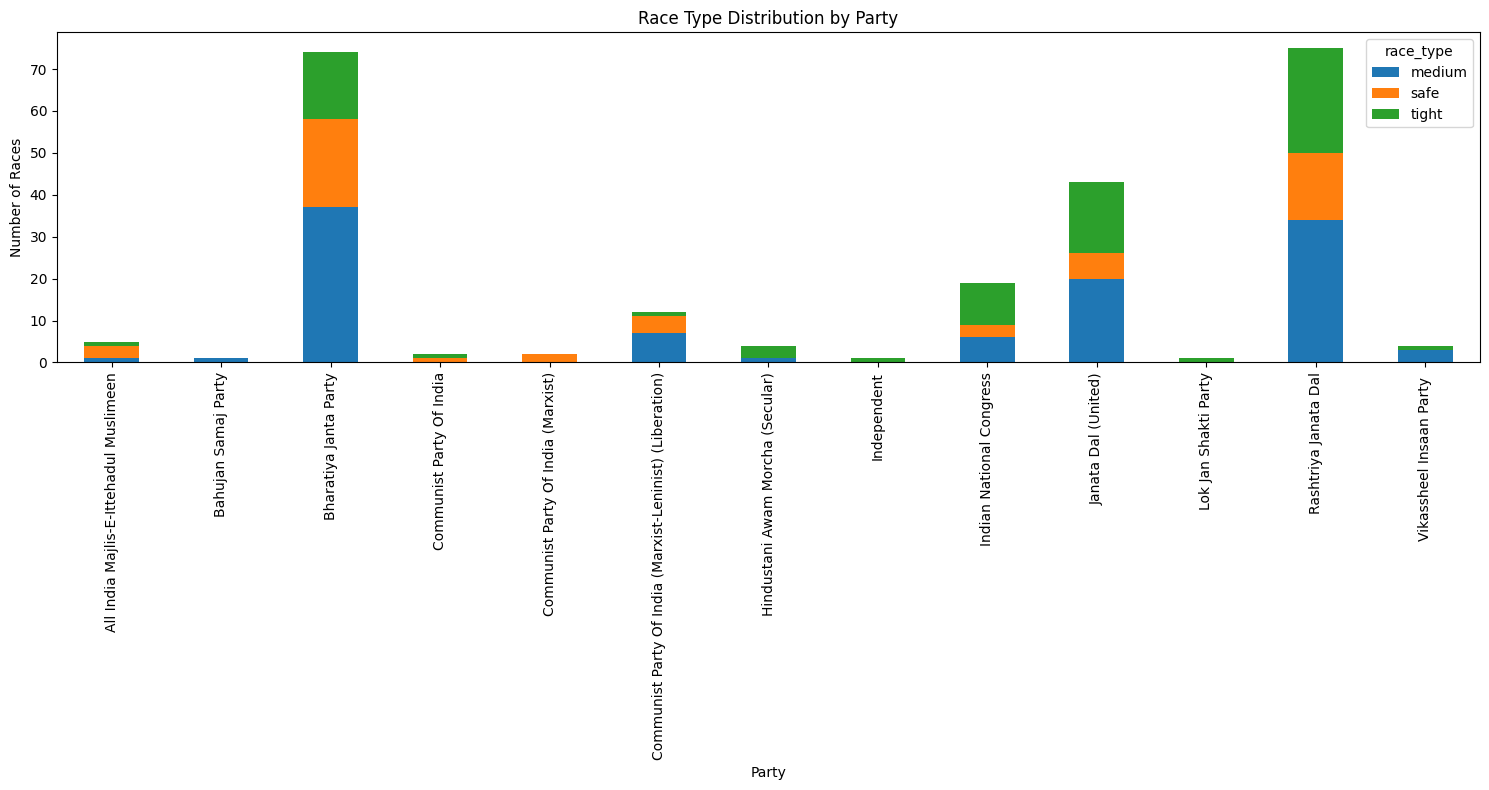

In [ ]:


import matplotlib.pyplot as plt

# Assuming race_type_by_party DataFrame from the previous step is available
# race_type_by_party = df.groupby('Party')['race_type'].value_counts().unstack(fill_value=0) # Uncomment if you run this cell independently

race_type_by_party.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Race Type Distribution by Party')
plt.xlabel('Party')
plt.ylabel('Number of Races')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

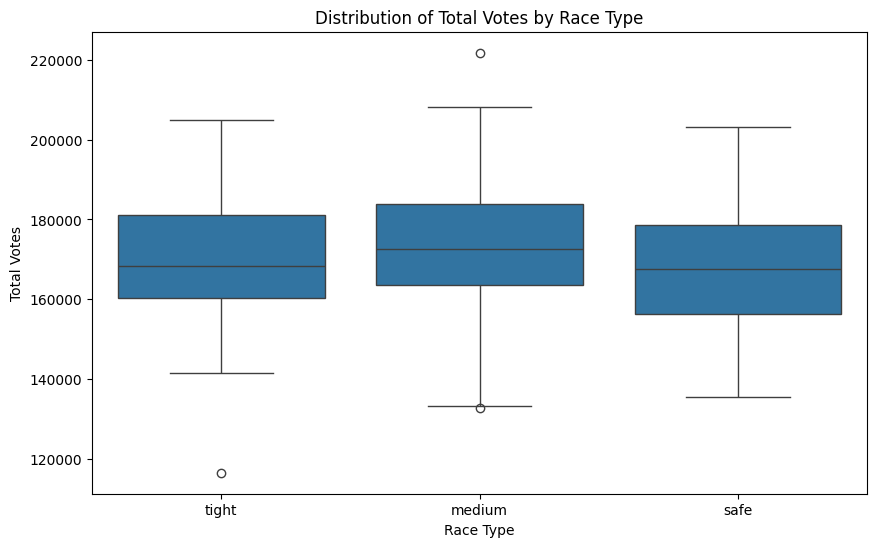

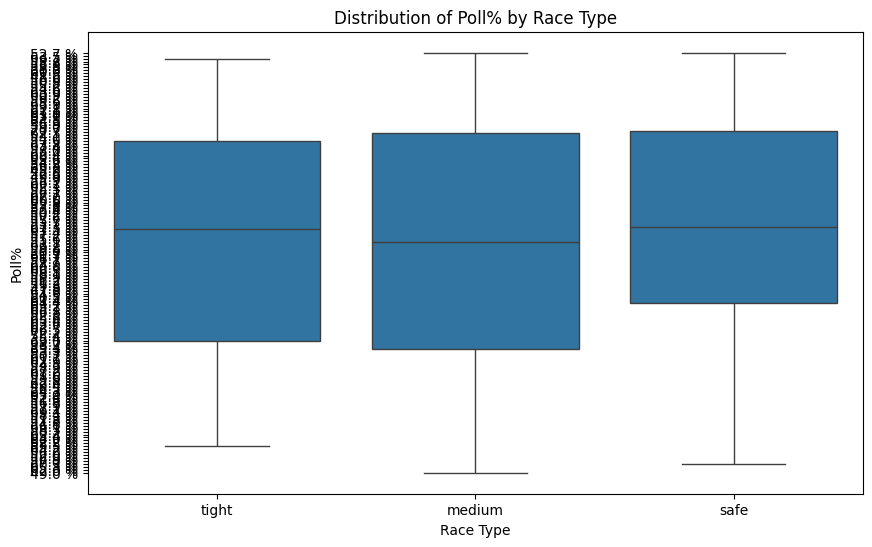

In [ ]:
# Analyze Total Votes by Race Type using Box Plots
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='race_type', y='Total Votes', data=df, order=['tight', 'medium', 'safe'])
plt.title('Distribution of Total Votes by Race Type')
plt.xlabel('Race Type')
plt.ylabel('Total Votes')
plt.show()

# Analyze Poll% by Race Type using Box Plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='race_type', y='Poll%', data=df, order=['tight', 'medium', 'safe'])
plt.title('Distribution of Poll% by Race Type')
plt.xlabel('Race Type')
plt.ylabel('Poll%')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_party = LabelEncoder()
le_district = LabelEncoder()
le_type = LabelEncoder()

df['Party'] = le_party.fit_transform(df['Party'])
df['District'] = le_district.fit_transform(df['District'])
df['Type'] = le_type.fit_transform(df['Type'])


In [ ]:
# see the encoded features
print("\nDataFrame head with encoded features:")
print(df.head())

# Display the mapping from original label to encoded number for each LabelEncoder
print("\nLabel Encoding Mappings:")
print("Party Mapping:", dict(zip(le_party.classes_, le_party.transform(le_party.classes_))))
print("District Mapping:", dict(zip(le_district.classes_, le_district.transform(le_district.classes_))))
print("Type Mapping:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))


DataFrame head with encoded features:
     AC Name  AC No.  Type  District       Winning Candidate  Party  \
0     Agiaon     195     0         6            Manoj Manzil      5   
1  Alamnagar      70     0        18  Narendra Narayan Yadav      9   
2     Alauli     148     0        15          Ramvriksh Sada     11   
3   Alinagar      81     0         8        Mishri Lal Yadav     12   
4    Amarpur     159     0         3              Jayant Raj      9   

   Total Electors  Total Votes   Poll%  Margin  Margin % race_type  
0          259645       136829  52.7 %   48550      35.5      safe  
1          327866       208234  63.5 %   28680      13.8    medium  
2          237047       141583  59.7 %    2773       2.0     tight  
3          264163       155218  58.8 %    3101       2.0     tight  
4          287342       160399  55.8 %    3114       1.9     tight  

Label Encoding Mappings:
Party Mapping: {'All India Majlis-E-Ittehadul Muslimeen': np.int64(0), 'Bahujan Samaj Party': 

In [ ]:
X = df[['Poll%', 'Total Votes', 'Total Electors', 'Party', 'District', 'Type']]
y = df['race_type']


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# You can also check the distribution of the target variable in the splits
print("\nDistribution of 'race_type' in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of 'race_type' in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (194, 6)
Shape of X_test: (49, 6)
Shape of y_train: (194,)
Shape of y_test: (49,)

Distribution of 'race_type' in y_train:
race_type
medium    0.453608
tight     0.314433
safe      0.231959
Name: proportion, dtype: float64

Distribution of 'race_type' in y_test:
race_type
medium    0.448980
tight     0.326531
safe      0.224490
Name: proportion, dtype: float64


In [ ]:

from sklearn.ensemble import RandomForestClassifier

# Initialize the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

# %%

RandomForestClassifier(random_state=42)

In [ ]:

# prompt: Evaluate the model

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model Evaluation:
Accuracy: 0.46938775510204084

Classification Report:
               precision    recall  f1-score   support

      medium       0.50      0.59      0.54        22
        safe       0.33      0.36      0.35        11
       tight       0.55      0.38      0.44        16

    accuracy                           0.47        49
   macro avg       0.46      0.44      0.44        49
weighted avg       0.48      0.47      0.47        49


Confusion Matrix:
 [[13  5  4]
 [ 6  4  1]
 [ 7  3  6]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on test set
y_pred = clf.predict(X_test)

# Print evaluation results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


[[13  5  4]
 [ 6  4  1]
 [ 7  3  6]]
              precision    recall  f1-score   support

      medium       0.50      0.59      0.54        22
        safe       0.33      0.36      0.35        11
       tight       0.55      0.38      0.44        16

    accuracy                           0.47        49
   macro avg       0.46      0.44      0.44        49
weighted avg       0.48      0.47      0.47        49

Accuracy: 0.46938775510204084


In [ ]:
import pickle

# Save model
with open('election_race_model.pkl', 'wb') as file:
    pickle.dump(clf, file)


To load the model, ensure that the cell saving the model (`cell_id: 63wQVlVzkgNY`) has been executed in the current runtime. The `FileNotFoundError` indicates that the saved model file was not found, likely because the runtime reset after the model was saved.

In [ ]:
import pickle

# Ensure the model is saved before loading
# This cell is a duplicate of cell 63wQVlVzkgNY to ensure the model file exists
try:
    with open('election_race_model.pkl', 'wb') as file:
        pickle.dump(clf, file)
    print("Model saved successfully.")
except Exception as e:
    print(f"Error saving model: {e}")


# Load model
try:
    with open('election_race_model.pkl', 'rb') as file:
        model = pickle.load(file)
    print("Model loaded successfully.")

    # Predict on new data (example sample)
    sample_data = X_test.iloc[:5]
    predictions = model.predict(sample_data)
    print("\nPredictions on sample data:")
    print(predictions)

except FileNotFoundError:
    print("Error: election_race_model.pkl not found. Please ensure the model saving cell was executed.")
except Exception as e:
    print(f"An error occurred while loading the model or making predictions: {e}")

Error saving model: name 'clf' is not defined
An error occurred while loading the model or making predictions: Ran out of input
